In [353]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

import cv2

from src.preprocessing import preprocess_image
from src.utils import show_image, show_images_grid


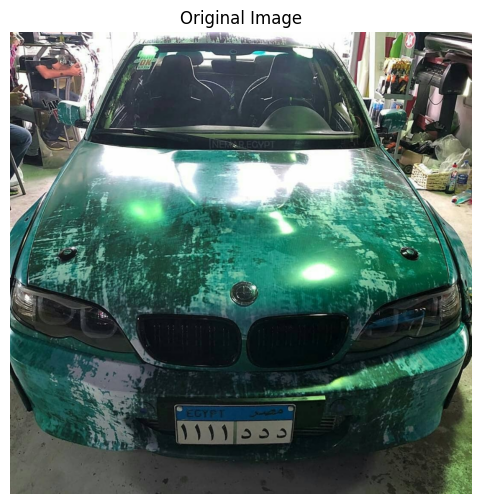

In [354]:
import importlib
import cv2
from pathlib import Path

import src.preprocessing as p
import src.detection as d
import src.utils as u

importlib.reload(p)
importlib.reload(d)
importlib.reload(u)

PROJECT_ROOT = Path("..").resolve()

image_path = PROJECT_ROOT / "Data" / "test_images" / "1470.jpg"

image = cv2.imread(str(image_path))

if image is None:
    raise ValueError("Image not found. Check image path.")

preprocessed = p.preprocess_image(image, width=900)

resized = preprocessed["resized"]
gray = preprocessed["gray"]

u.show_image("Original Image", resized)

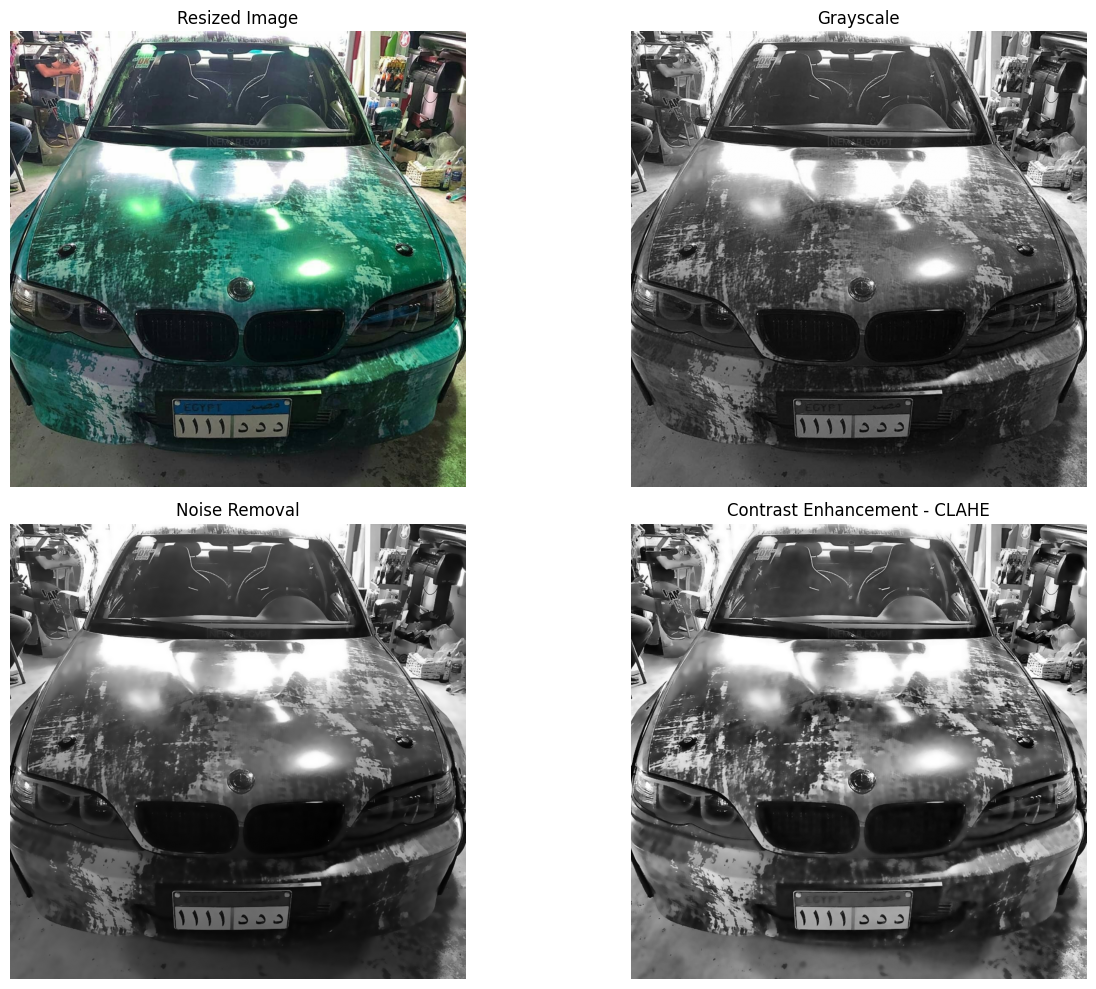

In [355]:
preprocessed = preprocess_image(image, width=900)

show_images_grid({
    "Resized Image": preprocessed["resized"],
    "Grayscale": preprocessed["gray"],
    "Noise Removal": preprocessed["denoised"],
    "Contrast Enhancement - CLAHE": preprocessed["enhanced"]
}, cols=2, figsize=(14, 10))

### Canny

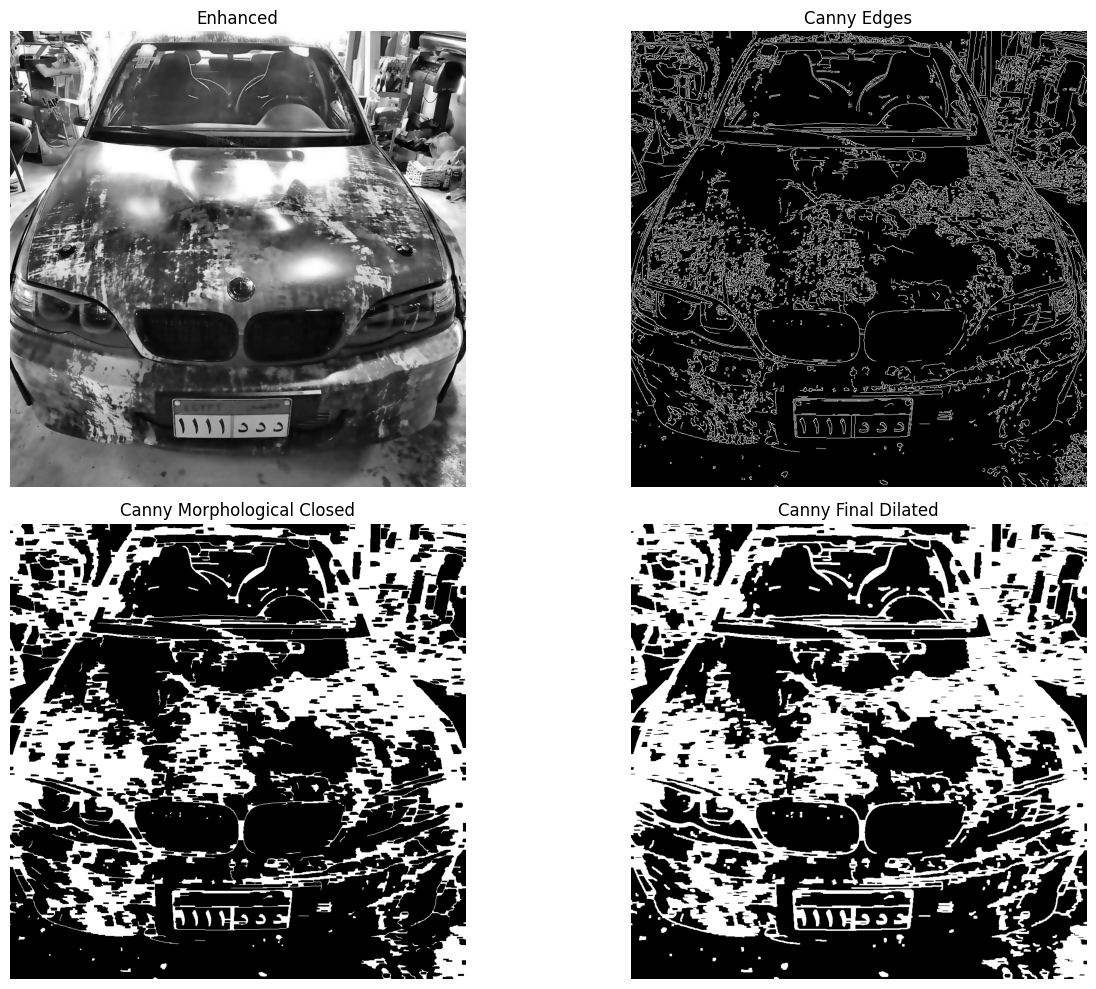

In [356]:
canny_output = d.canny_pipeline(gray)

u.show_images_grid({
    "Enhanced": canny_output["enhanced"],
    "Canny Edges": canny_output["edges"],
    "Canny Morphological Closed": canny_output["closed"],
    "Canny Final Dilated": canny_output["dilated"],
}, cols=2, figsize=(14, 10))

### canny Candidates

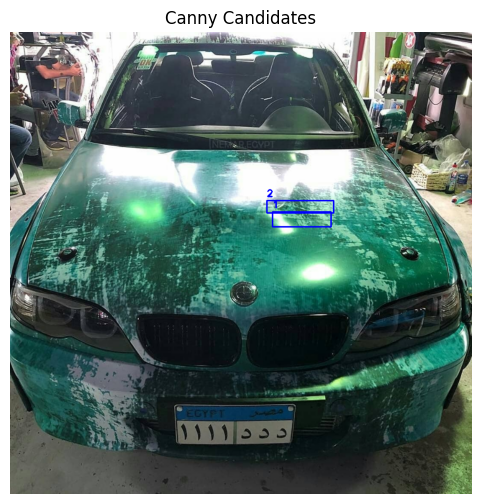

In [357]:
canny_candidates_image = d.draw_candidates(
    resized,
    canny_candidates
)

u.show_image(
    "Canny Candidates",
    canny_candidates_image
)

Canny Candidate 1
Box: (511, 350, 114, 29)
Aspect Ratio: 3.93
Area Ratio: 0.0033
Extent: 0.3
Center Y: 0.32
----------------------------------------


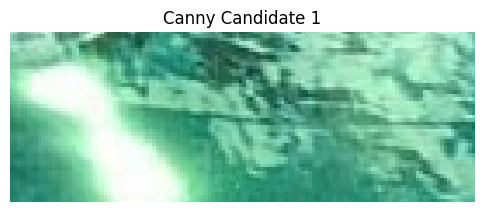

Canny Candidate 2
Box: (500, 328, 130, 24)
Aspect Ratio: 5.42
Area Ratio: 0.0031
Extent: 0.48
Center Y: 0.3
----------------------------------------


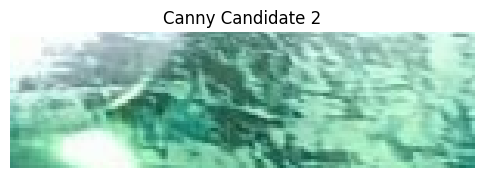

In [358]:
for i, candidate in enumerate(canny_candidates[:10]):
    crop = u.crop_with_padding(
        resized,
        candidate["box"],
        padding=10
    )

    print(f"Canny Candidate {i + 1}")
    print("Box:", candidate["box"])
    print("Aspect Ratio:", round(candidate["aspect_ratio"], 2))
    print("Area Ratio:", round(candidate["area_ratio"], 4))
    print("Extent:", round(candidate["extent"], 2))
    print("Center Y:", round(candidate["center_y"], 2))
    print("-" * 40)

    u.show_image(
        f"Canny Candidate {i + 1}",
        crop,
        figsize=(6, 3)
    )

### blackhat

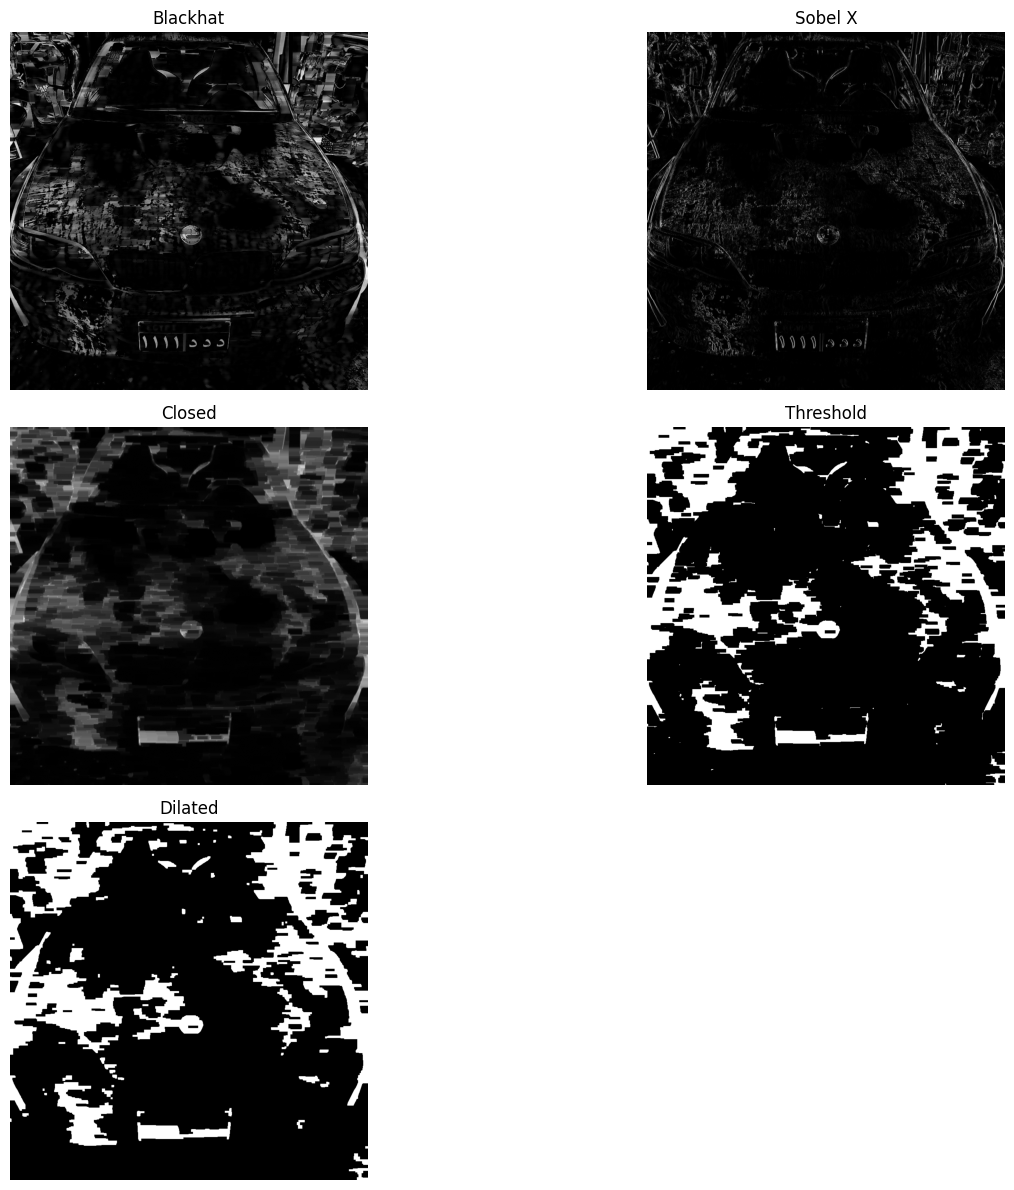

In [359]:
blackhat_output = d.blackhat_pipeline(gray)

u.show_images_grid({
    "Blackhat": blackhat_output["blackhat"],
    "Sobel X": blackhat_output["sobel_x"],
    "Closed": blackhat_output["closed"],
    "Threshold": blackhat_output["threshold"],
    "Dilated": blackhat_output["dilated"],
}, cols=2, figsize=(14, 12))

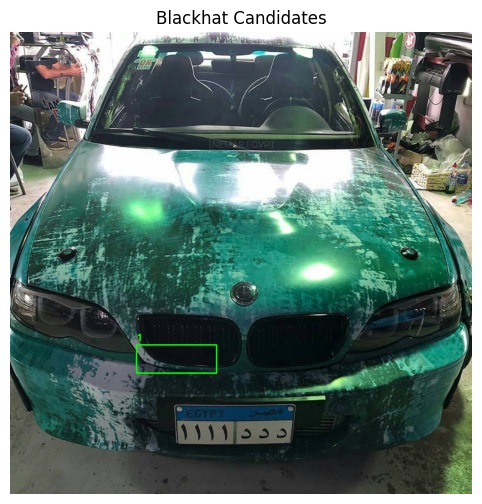

In [360]:
blackhat_candidates_image = d.draw_candidates(
    resized,
    blackhat_candidates
)

u.show_image(
    "Blackhat Candidates",
    blackhat_candidates_image
)

Blackhat Candidate 1
Box: (246, 609, 156, 55)
Aspect Ratio: 2.84
Area Ratio: 0.0085
Extent: 0.56
Center Y: 0.57
----------------------------------------


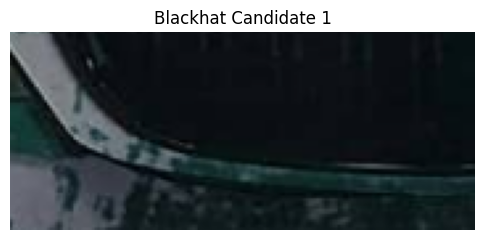

In [361]:
for i, candidate in enumerate(blackhat_candidates[:10]):
    crop = u.crop_with_padding(
        resized,
        candidate["box"],
        padding=10
    )

    print(f"Blackhat Candidate {i + 1}")
    print("Box:", candidate["box"])
    print("Aspect Ratio:", round(candidate["aspect_ratio"], 2))
    print("Area Ratio:", round(candidate["area_ratio"], 4))
    print("Extent:", round(candidate["extent"], 2))
    print("Center Y:", round(candidate["center_y"], 2))
    print("-" * 40)

    u.show_image(
        f"Blackhat Candidate {i + 1}",
        crop,
        figsize=(6, 3)
    )

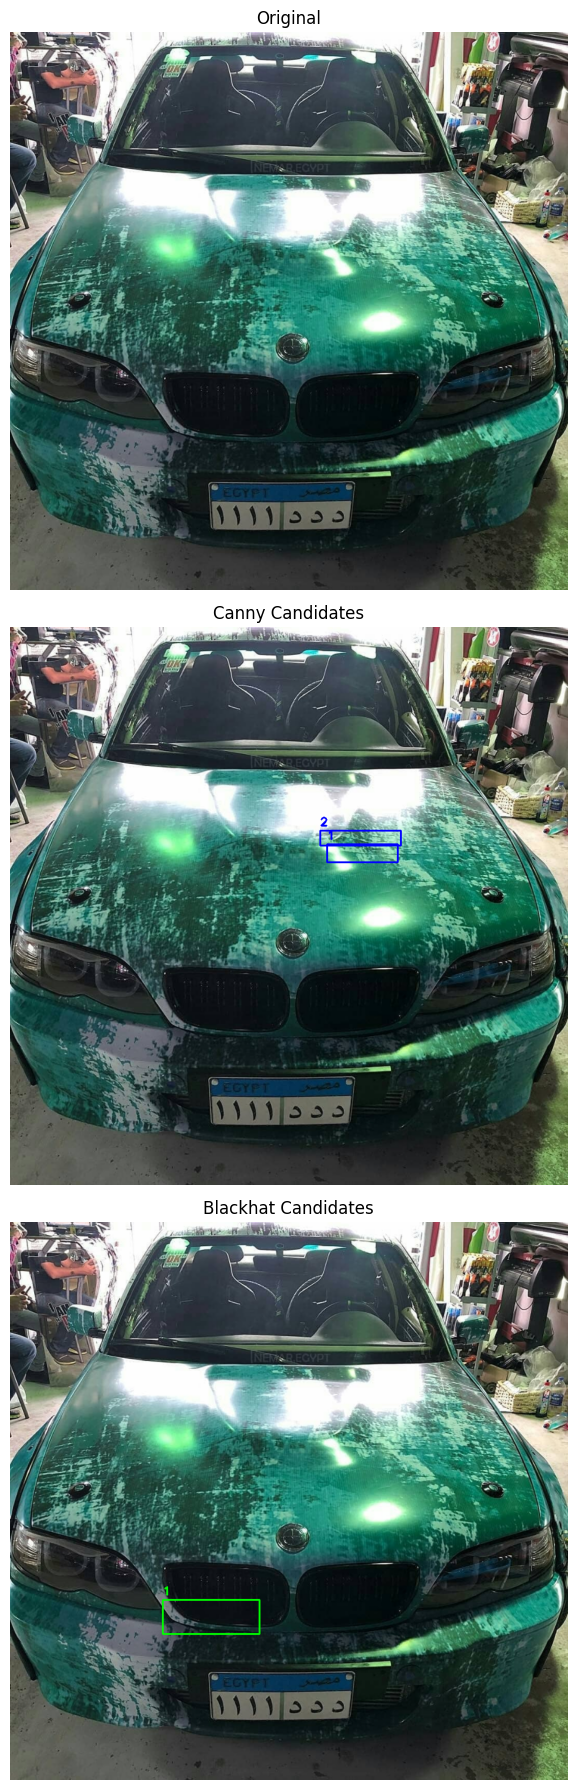

In [362]:
u.show_images_grid({
    "Original": resized,
    "Canny Candidates": canny_candidates_image,
    "Blackhat Candidates": blackhat_candidates_image,
}, cols=1, figsize=(12, 18))